# PO Delay Root Cause Analyzer: Data Pipeline and EDA

**Objetivo de la semana:** Cargar, limpiar, validar y explorar el dataset de Purchase Orders. Entregar un DataFrame limpio con todos los deltas calculados, listo para la clasificación de la semana 2.

**Output final:** df_clean.csv

---

### 1. Setup & Imports

In [ ]:
# Instalar dependencias
import os, warnings, matplotlib.pyplot as plt, matplotlib.ticker as mticker, numpy as np, pandas as pd, seaborn as sns
from scipy import stats
#warnings.filterwarnings('ignore')

# ESTILO GLOBAL DE GRÁFICAS
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True, 'grid.color': '#e8e8e8', 'grid.linewidth': 0.6, 'font.family': 'DejaVu Sans', 'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.labelsize': 11, 'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9, 'figure.dpi': 130})

# PALETAS DE COLORES CORPORATIVAS
PALETTE_MAIN, PALETTE_LATE, PALETTE_ONTIME, PALETTE_WARN = '#4C72B0', '#DD5C5C', '#55A868', '#F0A500'

print('✅ Setup completo')


✅ Setup completo


## 2. Carga & Inventario de Columnas

In [ ]:
# 1. CARGA DE DATOS DESDE GITHUB
CSV_PATH = f'https://raw.githubusercontent.com/johnnalm360/po_delay_root_cause_analyzer/main/po_root_cause_synthetic.csv'
df_raw = pd.read_csv(CSV_PATH, low_memory=False)

# 2. REPORTE DE CALIDAD (Diccionario en una sola línea)
null_report = pd.DataFrame({'dtype': df_raw.dtypes, 'nulls': df_raw.isnull().sum(), 'null_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1), 'unique': df_raw.nunique()})
print('=== DIAGNÓSTICO DE COLUMNAS ===\n', null_report.to_string(), '\n\n=== PRIMERAS 5 FILAS DEL DATASET ===')

# 3. MUESTRA DE TABLA
display(df_raw.head(1))


=== DIAGNÓSTICO DE COLUMNAS ===
                             dtype  nulls  null_pct  unique
PO_NBR                      int64      0       0.0     400
PO_DT                      object      0       0.0     101
VENDOR_NBR                  int64      0       0.0      10
VENDOR_NAME                object      0       0.0      10
PAY_VENDOR_NBR              int64      0       0.0      10
PAY_VENDOR_NAME            object      0       0.0      10
DC_ID                       int64      0       0.0       8
DC_LOC_NAME                object      0       0.0       8
DC_FACILITY_CD_ABBREV      object      0       0.0       8
PO_STATUS_CD               object      0       0.0       1
STA_DT                     object      0       0.0     144
RECPT_DT                   object      0       0.0     400
TOT_ORG_QTY                 int64      0       0.0     363
TOT_ON_ORD_QTY              int64      0       0.0     357
TOT_ADJ_QTY                 int64      0       0.0      82
TOT_RCVD_QTY           

,PO_NBR,PO_DT,VENDOR_NBR,VENDOR_NAME,PAY_VENDOR_NBR,PAY_VENDOR_NAME,DC_ID,DC_LOC_NAME,DC_FACILITY_CD_ABBREV,PO_STATUS_CD,...,CHECKOUT_DT,TRAILER_DEPART_DT,CARRIER_PARTY_NAME,TRAILER_NBR,REASON_CD,REASON_DSC,IS_LATE,DELAY_DAYS,YARD_WAIT_HRS,DOCK_HRS
0,100000,2025-05-05,67441,SYNCO,50400,SYNCO DISTRIBUTION,5003,Phoenix DC,PX,C,...,2025-05-14 04:58:01,2025-05-14 10:47:00,Werner Enterprises,TRL50538,RS,Rescheduled by vendor,Y,3.5,0.6,2.9


## 3. Limpieza de Timestamps y Validación de Calidad

In [ ]:
# == 3.1 PARSEAR TODAS LAS COLUMNAS DE FECHA A DATETIME ==
df = df_raw.copy()
DATE_COLS = ['PO_DT', 'STA_DT', 'RECPT_DT', 'REQUESTED_DT', 'FIRST_SUBMITTED_DT', 'DT_APPT_FIRST_APPROVED', 'APPROVED_DT', 'DT_APPT_CURRENT_APPROVED', 'PREVIOUS_REQUEST_DT', 'TRAILER_ARRIVE_DT', 'CHECKIN_DT', 'CHECKOUT_DT', 'TRAILER_DEPART_DT']

for col in DATE_COLS: df[col] = pd.to_datetime(df[col], errors='coerce')

print('✅ Timestamps parseados. NaTs por columna:')
nat_counts = {c: df[c].isna().sum() for c in DATE_COLS if df[c].isna().sum() > 0}
for col, count in nat_counts.items(): print(f'   {col:<35} {count:>3} NaTs ({count/len(df)*100:.1f}%)')

# == 3.2 DETECTAR TIMESTAMPS FUERA DE ORDEN ==
print('\n── Validación de orden cronológico ─────────────────────────────────────')
checks = [
    ('CHECKIN antes de TRAILER_ARRIVE',  df['CHECKIN_DT']        < df['TRAILER_ARRIVE_DT']),
    ('CHECKOUT antes de CHECKIN',         df['CHECKOUT_DT']       < df['CHECKIN_DT']),
    ('TRAILER_ARRIVE antes de APPROVED',  df['TRAILER_ARRIVE_DT'] < df['APPROVED_DT'] - pd.Timedelta(days=7)),
    ('RECPT antes de CHECKIN',            df['RECPT_DT']          < df['CHECKIN_DT']),
    ('STA antes de PO_DT',               df['STA_DT']            < df['PO_DT']),
]

ts_issues = pd.Series(False, index=df.index)
for check_name, mask in checks:
    n = mask.sum()
    ts_issues = ts_issues | mask
    print(f"  {'⚠️ ' if n > 0 else '✅'} {check_name:<40} {n:>3} registros")

df['_ts_issue'], df['_trailer_arrive_null'] = ts_issues, df['TRAILER_ARRIVE_DT'].isna()
print(f'\n  Total POs con algún problema de timestamp: {ts_issues.sum()}\n  Total POs con TRAILER_ARRIVE_DT null:      {df["_trailer_arrive_null"].sum()}\n  Total POs con datos confiables:            {(~ts_issues & ~df["_trailer_arrive_null"]).sum()}')

# == 3.3 DETECTAR APPOINTMENTS REPROGRAMADOS Y 3.4 SHORT SHIP FLAG ==
df['_rescheduled'] = (df['DT_APPT_CURRENT_APPROVED'] != df['DT_APPT_FIRST_APPROVED']).fillna(False)
df['_short_ship'] = (df['NUM_CASES_SHIPPED'] / df['NUM_CASES_ORDERED'].replace(0, np.nan)) < 0.90
df['_fill_rate'] = (df['NUM_CASES_SHIPPED'] / df['NUM_CASES_ORDERED'].replace(0, np.nan)).clip(0, 1)

print(f'\n  POs con appointment reprogramado: {df["_rescheduled"].sum()} ({df["_rescheduled"].mean()*100:.1f}%)')
print(f'  Short ship POs (<90% fill rate):  {df["_short_ship"].sum()} ({df["_short_ship"].mean()*100:.1f}%)')


✅ Timestamps parseados. NaTs por columna:
   PREVIOUS_REQUEST_DT                 337 NaTs (84.2%)
   TRAILER_ARRIVE_DT                    27 NaTs (6.8%)

── Validación de orden cronológico ─────────────────────────────────────
  ✅ CHECKIN antes de TRAILER_ARRIVE            0 registros
  ⚠️  CHECKOUT antes de CHECKIN                 12 registros
  ✅ TRAILER_ARRIVE antes de APPROVED           0 registros
  ✅ RECPT antes de CHECKIN                     0 registros
  ✅ STA antes de PO_DT                         0 registros

  Total POs con algún problema de timestamp: 12
  Total POs con TRAILER_ARRIVE_DT null:      27
  Total POs con datos confiables:            361

  POs con appointment reprogramado: 63 (15.8%)
  Short ship POs (<90% fill rate):  23 (5.8%)


## 4. Cálculo de Deltas y Métricas

In [ ]:
# ── 4.1 Deltas de tiempo ─────────────────────────────────────────────────────

# Lead time del PO (días hábiles no calculados aquí, solo días calendario)
df['lead_time_days'] = (df['STA_DT'] - df['PO_DT']).dt.total_seconds() / 86400

# Carrier lag: tiempo entre appointment aprobado y llegada del trailer
df['carrier_lag_hrs'] = (
    (df['TRAILER_ARRIVE_DT'] - df['APPROVED_DT']).dt.total_seconds() / 3600
)

# Yard wait: tiempo en patio esperando dock (recalculado para cross-validation)
df['yard_wait_calc_hrs'] = (
    (df['CHECKIN_DT'] - df['TRAILER_ARRIVE_DT']).dt.total_seconds() / 3600
).clip(lower=0)  # eliminar negativos por timestamps inválidos

# Dock processing: tiempo de procesamiento en puerta
df['dock_calc_hrs'] = (
    (df['CHECKOUT_DT'] - df['CHECKIN_DT']).dt.total_seconds() / 3600
).clip(lower=0)

# Tiempo total en DC (arrive → checkout)
df['total_dc_hrs'] = (
    (df['CHECKOUT_DT'] - df['TRAILER_ARRIVE_DT']).dt.total_seconds() / 3600
).clip(lower=0)

# Scheduling lead: cuánto antes del STA se aprobó el appointment
df['appt_lead_days'] = (
    (df['STA_DT'] - df['APPROVED_DT']).dt.total_seconds() / 86400
)

# Delay real recalculado
df['delay_days_calc'] = (
    (df['RECPT_DT'] - df['STA_DT']).dt.total_seconds() / 86400
).clip(lower=0)


# ── 4.2 Cross-validation: mis cálculos vs columnas pre-calculadas ────────────
print('── Cross-validation: calculados vs pre-calculados ───────────────────────')

delta_yard = (df['yard_wait_calc_hrs'] - df['YARD_WAIT_HRS']).abs()
delta_dock = (df['dock_calc_hrs'] - df['DOCK_HRS']).abs()
delta_delay = (df['delay_days_calc'] - df['DELAY_DAYS']).abs()

print(f'  YARD_WAIT_HRS  — diferencia media: {delta_yard.mean():.3f}h, max: {delta_yard.max():.3f}h')
print(f'  DOCK_HRS       — diferencia media: {delta_dock.mean():.3f}h, max: {delta_dock.max():.3f}h')
print(f'  DELAY_DAYS     — diferencia media: {delta_delay.mean():.3f}d, max: {delta_delay.max():.3f}d')

# Marcar discrepancias significativas
df['_yard_discrepancy'] = delta_yard > 1.0
df['_dock_discrepancy'] = delta_dock > 1.0

print(f'\n  POs con discrepancia de yard > 1h: {df["_yard_discrepancy"].sum()}')
print(f'  POs con discrepancia de dock > 1h: {df["_dock_discrepancy"].sum()}')


# ── 4.3 Flags de clasificación preliminar ────────────────────────────────────
YARD_THRESHOLD_HRS = 4.0
DOCK_THRESHOLD_HRS = 6.0
CARRIER_MISS_HRS   = 4.0   # llegó >4h tarde a su ventana de appointment
SHORT_LEAD_DAYS    = 3.0

df['flag_yard_congestion'] = df['YARD_WAIT_HRS'] > YARD_THRESHOLD_HRS
df['flag_dock_backlog']    = df['DOCK_HRS']      > DOCK_THRESHOLD_HRS
df['flag_carrier_miss']    = df['carrier_lag_hrs'] > CARRIER_MISS_HRS
df['flag_short_lead_time'] = df['lead_time_days']  < SHORT_LEAD_DAYS
df['flag_hot_late']        = (df['HOT_PO_FLAG'] == 1) & (df['IS_LATE'] == 'Y')

print('\n── Flags de clasificación preliminar ───────────────────────────────────')
flags = ['flag_yard_congestion','flag_dock_backlog','flag_carrier_miss',
         'flag_short_lead_time','flag_hot_late']
for f in flags:
    n = df[f].sum()
    print(f'  {f:<30} {n:>3} POs ({n/len(df)*100:.1f}%)')

print('\n✅ Deltas calculados y flags asignadas')

── Cross-validation: calculados vs pre-calculados ───────────────────────
  YARD_WAIT_HRS  — diferencia media: 0.024h, max: 0.050h
  DOCK_HRS       — diferencia media: 0.127h, max: 8.200h
  DELAY_DAYS     — diferencia media: 0.277d, max: 0.996d

  POs con discrepancia de yard > 1h: 0
  POs con discrepancia de dock > 1h: 11

── Flags de clasificación preliminar ───────────────────────────────────
  flag_yard_congestion            52 POs (13.0%)
  flag_dock_backlog               24 POs (6.0%)
  flag_carrier_miss              103 POs (25.8%)
  flag_short_lead_time             0 POs (0.0%)
  flag_hot_late                   20 POs (5.0%)

✅ Deltas calculados y flags asignadas


## 5. EDA — Análisis exploratorio de Datos


### 5.1 Distribución Global de Delays

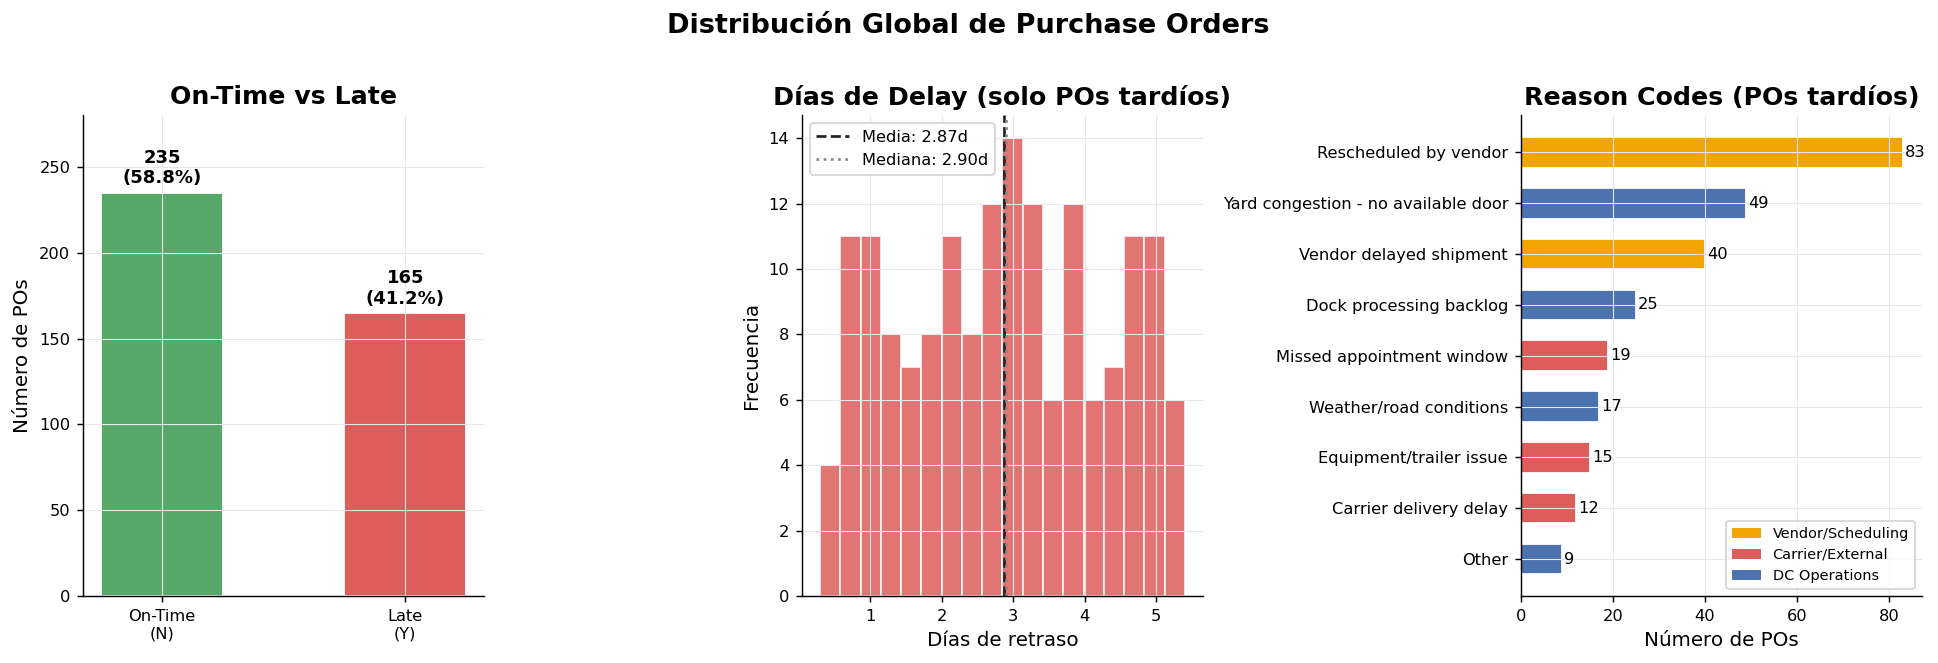

── Estadísticas de DELAY_DAYS (todos los POs) ──────────────────────────
count    400.000
mean       1.182
std        1.674
min        0.000
25%        0.000
50%        0.000
75%        2.500
max        5.400
Name: DELAY_DAYS, dtype: float64

Delay medio (solo tardíos): 2.87 días
POs con >3 días de retraso: 75


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribución Global de Purchase Orders', fontsize=15, fontweight='bold', y=1.01)

# ── Plot 1: On-Time vs Late ──────────────────────────────────────────────────
ax = axes[0]
late_counts = df['IS_LATE'].value_counts()
colors = [PALETTE_LATE if x == 'Y' else PALETTE_ONTIME for x in late_counts.index]
bars = ax.bar(['On-Time\n(N)', 'Late\n(Y)'],
              [late_counts.get('N', 0), late_counts.get('Y', 0)],
              color=[PALETTE_ONTIME, PALETTE_LATE], width=0.5, edgecolor='white')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 3, f'{h}\n({h/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('On-Time vs Late')
ax.set_ylabel('Número de POs')
ax.set_ylim(0, 280)

# ── Plot 2: Distribución de DELAY_DAYS (solo tardíos) ───────────────────────
ax = axes[1]
late_df = df[df['IS_LATE'] == 'Y']
ax.hist(late_df['DELAY_DAYS'], bins=18, color=PALETTE_LATE, alpha=0.85, edgecolor='white')
ax.axvline(late_df['DELAY_DAYS'].mean(), color='#222', linestyle='--', linewidth=1.5,
           label=f'Media: {late_df["DELAY_DAYS"].mean():.2f}d')
ax.axvline(late_df['DELAY_DAYS'].median(), color='#888', linestyle=':', linewidth=1.5,
           label=f'Mediana: {late_df["DELAY_DAYS"].median():.2f}d')
ax.legend()
ax.set_title('Días de Delay (solo POs tardíos)')
ax.set_xlabel('Días de retraso')
ax.set_ylabel('Frecuencia')

# ── Plot 3: Reason Code distribution ────────────────────────────────────────
ax = axes[2]
reason_counts = df['REASON_DSC'].value_counts().drop('Not applicable', errors='ignore')
reason_counts = reason_counts.sort_values(ascending=True)
colors_reason = [PALETTE_WARN if 'Rescheduled' in r or 'Vendor' in r
                 else PALETTE_LATE if 'Carrier' in r or 'Missed' in r or 'Equipment' in r
                 else PALETTE_MAIN for r in reason_counts.index]
bars = ax.barh(reason_counts.index, reason_counts.values,
               color=colors_reason, edgecolor='white', height=0.6)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2, str(int(w)),
            va='center', fontsize=9)
ax.set_title('Reason Codes (POs tardíos)')
ax.set_xlabel('Número de POs')

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE_WARN,   label='Vendor/Scheduling'),
    Patch(facecolor=PALETTE_LATE,   label='Carrier/External'),
    Patch(facecolor=PALETTE_MAIN,   label='DC Operations'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('eda_01_distribucion_global.png', dpi=130, bbox_inches='tight')
plt.show()

# Estadísticas descriptivas
print('── Estadísticas de DELAY_DAYS (todos los POs) ──────────────────────────')
print(df['DELAY_DAYS'].describe().round(3))
print(f'\nDelay medio (solo tardíos): {late_df["DELAY_DAYS"].mean():.2f} días')
print(f'POs con >3 días de retraso: {(df["DELAY_DAYS"]>3).sum()}')

### 5.2 Análisis por Distribution Center

### 5.3 Análisis por Vendor y Carrier

### 5.4 Reason Code Analysis + Mismatch Detection

### 5.5 HOT POs, Short Shipments y Casos Críticos

### 5.6 Mapa de Correlaciones

## 6. Función "clean_po_data()" — Output Reutilizable

In [ ]:
def clean_po_data(df_input: pd.DataFrame) -> pd.DataFrame:
    """
    Pipeline de limpieza y enriquecimiento del dataset de PO Root Cause.

    Input:  DataFrame crudo del CSV po_root_cause_synthetic.csv
    Output: DataFrame enriquecido con:
            - Timestamps parseados a datetime
            - Flags de calidad de datos (_ts_issue, _trailer_arrive_null)
            - Deltas calculados (yard_wait_calc_hrs, dock_calc_hrs, carrier_lag_hrs, etc.)
            - Flags de clasificación (flag_yard_congestion, flag_dock_backlog, etc.)
            - Flags operacionales (_rescheduled, _short_ship, _fill_rate)
    """
    df = df_input.copy()

    # ── 1. Parsear timestamps ────────────────────────────────────────────────
    DATE_COLS = [
        'PO_DT', 'STA_DT', 'RECPT_DT',
        'REQUESTED_DT', 'FIRST_SUBMITTED_DT',
        'DT_APPT_FIRST_APPROVED', 'APPROVED_DT', 'DT_APPT_CURRENT_APPROVED',
        'PREVIOUS_REQUEST_DT',
        'TRAILER_ARRIVE_DT', 'CHECKIN_DT', 'CHECKOUT_DT', 'TRAILER_DEPART_DT'
    ]
    for col in DATE_COLS:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    # ── 2. Flags de calidad ──────────────────────────────────────────────────
    df['_trailer_arrive_null'] = df['TRAILER_ARRIVE_DT'].isna()
    df['_ts_issue'] = (
        (df['CHECKIN_DT']  < df['TRAILER_ARRIVE_DT']) |
        (df['CHECKOUT_DT'] < df['CHECKIN_DT'])         |
        (df['RECPT_DT']    < df['CHECKIN_DT'])         |
        (df['STA_DT']      < df['PO_DT'])
    ).fillna(False)
    df['_data_reliable'] = (~df['_ts_issue']) & (~df['_trailer_arrive_null'])

    # ── 3. Métricas operacionales ────────────────────────────────────────────
    df['_rescheduled'] = (
        df['DT_APPT_CURRENT_APPROVED'] != df['DT_APPT_FIRST_APPROVED']
    ).fillna(False)

    df['_fill_rate'] = (
        df['NUM_CASES_SHIPPED'] / df['NUM_CASES_ORDERED'].replace(0, np.nan)
    ).clip(0, 1)
    df['_short_ship'] = df['_fill_rate'] < 0.90

    # ── 4. Deltas de tiempo ──────────────────────────────────────────────────
    def hrs(series): return series.dt.total_seconds() / 3600
    def days(series): return series.dt.total_seconds() / 86400

    df['lead_time_days']    = days(df['STA_DT']            - df['PO_DT']).clip(lower=0)
    df['carrier_lag_hrs']   = hrs(df['TRAILER_ARRIVE_DT']  - df['APPROVED_DT'])
    df['yard_wait_calc_hrs']= hrs(df['CHECKIN_DT']         - df['TRAILER_ARRIVE_DT']).clip(lower=0)
    df['dock_calc_hrs']     = hrs(df['CHECKOUT_DT']        - df['CHECKIN_DT']).clip(lower=0)
    df['total_dc_hrs']      = hrs(df['CHECKOUT_DT']        - df['TRAILER_ARRIVE_DT']).clip(lower=0)
    df['appt_lead_days']    = days(df['STA_DT']            - df['APPROVED_DT'])
    df['delay_days_calc']   = days(df['RECPT_DT']          - df['STA_DT']).clip(lower=0)

    # ── 5. Flags de clasificación por etapa ──────────────────────────────────
    YARD_THR    = 4.0
    DOCK_THR    = 6.0
    CARRIER_THR = 4.0
    LEAD_THR    = 3.0

    df['flag_yard_congestion'] = df['YARD_WAIT_HRS'] > YARD_THR
    df['flag_dock_backlog']    = df['DOCK_HRS']      > DOCK_THR
    df['flag_carrier_miss']    = df['carrier_lag_hrs'] > CARRIER_THR
    df['flag_short_lead_time'] = df['lead_time_days']  < LEAD_THR
    df['flag_hot_late']        = (df['HOT_PO_FLAG'] == 1) & (df['IS_LATE'] == 'Y')

    return df


# ── Ejecutar y validar ───────────────────────────────────────────────────────
df_clean = clean_po_data(df_raw)

print('✅ clean_po_data() ejecutado correctamente')
print(f'   Shape:                      {df_clean.shape}')
print(f'   Columnas agregadas:         {df_clean.shape[1] - df_raw.shape[1]}')
print(f'   POs con datos confiables:   {df_clean["_data_reliable"].sum()} / {len(df_clean)}')
print(f'   POs rescheduled:            {df_clean["_rescheduled"].sum()}')
print(f'   Short ships:                {df_clean["_short_ship"].sum()}')
print(f'   Flag yard congestion:       {df_clean["flag_yard_congestion"].sum()}')
print(f'   Flag dock backlog:          {df_clean["flag_dock_backlog"].sum()}')
print(f'   Flag carrier miss:          {df_clean["flag_carrier_miss"].sum()}')

# Nuevas columnas
new_cols = [c for c in df_clean.columns if c not in df_raw.columns]
print(f'\nColumnas nuevas: {new_cols}')

✅ clean_po_data() ejecutado correctamente
   Shape:                      (400, 57)
   Columnas agregadas:         18
   POs con datos confiables:   361 / 400
   POs rescheduled:            63
   Short ships:                23
   Flag yard congestion:       52
   Flag dock backlog:          24
   Flag carrier miss:          103

Columnas nuevas: ['_trailer_arrive_null', '_ts_issue', '_data_reliable', '_rescheduled', '_fill_rate', '_short_ship', 'lead_time_days', 'carrier_lag_hrs', 'yard_wait_calc_hrs', 'dock_calc_hrs', 'total_dc_hrs', 'appt_lead_days', 'delay_days_calc', 'flag_yard_congestion', 'flag_dock_backlog', 'flag_carrier_miss', 'flag_short_lead_time', 'flag_hot_late']


## 7. Guardar Output y Resumen de Hallazgos